# Bayesian optimization on a 2D loss surface

**Goal:** find a low value of a scalar loss $f(x, y)$ while evaluating as few points as possible. Run the cells from top to bottom. Each figure shows what the optimizer knows *before* it evaluates the next point.

We can display the entire synthetic loss surface because we wrote the function. The optimizer itself only receives the values at the points it requests.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.exceptions import ConvergenceWarning

from bopt import BayesianOptimization

# Sparse data can put a GP length scale at its search bound during early fits.
warnings.filterwarnings(
    "ignore", category=ConvergenceWarning, module="sklearn.gaussian_process"
)

SEED = 4
BOUNDS = (-2.5, 2.5)
N_INITIAL = 8
N_EI_STEPS = 7


## 1. Make the surface

The two negative Gaussian bumps form two valleys. A small quadratic term and ripple make the landscape less symmetric. Lower values are better. `imshow` samples this function on a dense grid; it is a teaching reference, not data given to the optimizer.


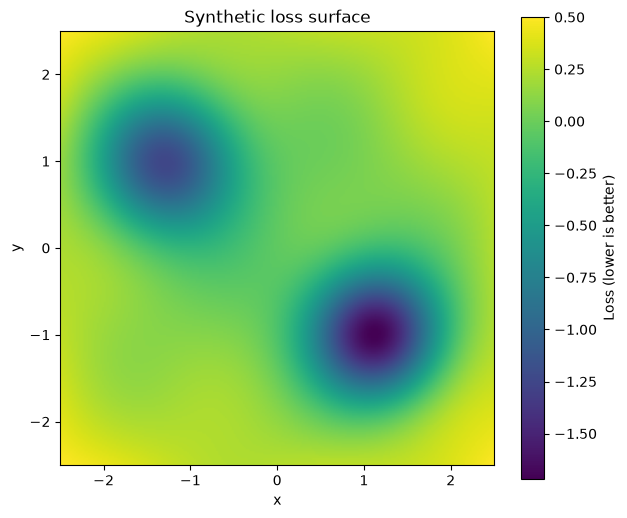

In [2]:
def loss(x, y):
    x, y = np.asarray(x), np.asarray(y)
    return (
        0.04 * (x**2 + y**2)
        - 1.35 * np.exp(-((x + 1.3)**2 + (y - 1.0)**2) / 0.65)
        - 1.80 * np.exp(-((x - 1.15)**2 + (y + 1.0)**2) / 0.55)
        + 0.08 * np.sin(2.5 * x) * np.cos(2.0 * y)
    )

axis = np.linspace(*BOUNDS, 250)
XX, YY = np.meshgrid(axis, axis)
ZZ = loss(XX, YY)
extent = (*BOUNDS, *BOUNDS)

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(ZZ, origin="lower", extent=extent, cmap="viridis", aspect="equal")
fig.colorbar(image, ax=ax, label="Loss (lower is better)")
ax.set(xlabel="x", ylabel="y", title="Synthetic loss surface")
plt.show()


## 2. Gather well spread starting points

A scrambled Sobol sequence supplies eight initial locations. These are evaluated before a GP is fitted. The fixed seed makes the walkthrough reproducible.


Start 1: x=+1.966, y=-1.971, loss=+0.268
Start 2: x=-2.201, y=+1.573, loss=+0.003
Start 3: x=-0.733, y=-1.035, loss=+0.097
Start 4: x=+0.968, y=+0.012, loss=-0.173
Start 5: x=+0.562, y=-0.439, loss=-0.471
Start 6: x=-0.171, y=+0.666, loss=-0.150
Start 7: x=-1.834, y=-1.375, loss=+0.137
Start 8: x=+1.443, y=+2.227, loss=+0.291


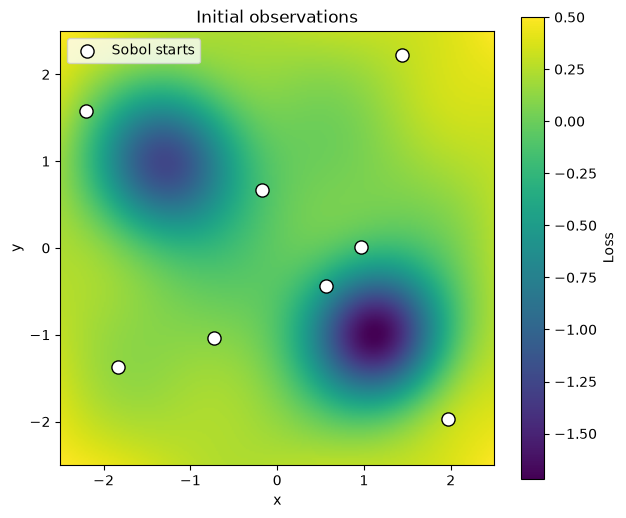

In [3]:
optimizer = BayesianOptimization(
    {"x": BOUNDS, "y": BOUNDS},
    minimize=True,
    random_inits=N_INITIAL,
    n_candidates=1024,
    random_state=SEED,
)

for step in range(N_INITIAL):
    trial = optimizer.get_next_trial()
    trial.update(float(loss(**trial.parameters)))
    print(f"Start {step + 1}: x={trial.parameters['x']:+.3f}, "
          f"y={trial.parameters['y']:+.3f}, loss={trial.result:+.3f}")

starts = np.array([[t.parameters["x"], t.parameters["y"]] for t in optimizer.trials])
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(ZZ, origin="lower", extent=extent, cmap="viridis", aspect="equal")
ax.scatter(starts[:, 0], starts[:, 1], s=90, color="white", edgecolor="black", label="Sobol starts")
fig.colorbar(image, ax=ax, label="Loss")
ax.set(xlabel="x", ylabel="y", title="Initial observations")
ax.legend()
plt.show()


## 3. Let expected improvement pick the next experiment

The Gaussian process (GP) estimates a mean loss and uncertainty from completed trials. For minimization, expected improvement at a point is

$$\operatorname{EI}(x,y) = \mathbb{E}[\max(f_{\mathrm{best}} - F(x,y), 0)].$$

EI can favor a predicted low loss **or** a region with enough uncertainty to hide a better result. Each row of the next figures shows the real surface, the GP mean, and EI. The red X is the next point, selected from a finite Sobol candidate pool. Only after plotting do we evaluate it and update the GP.


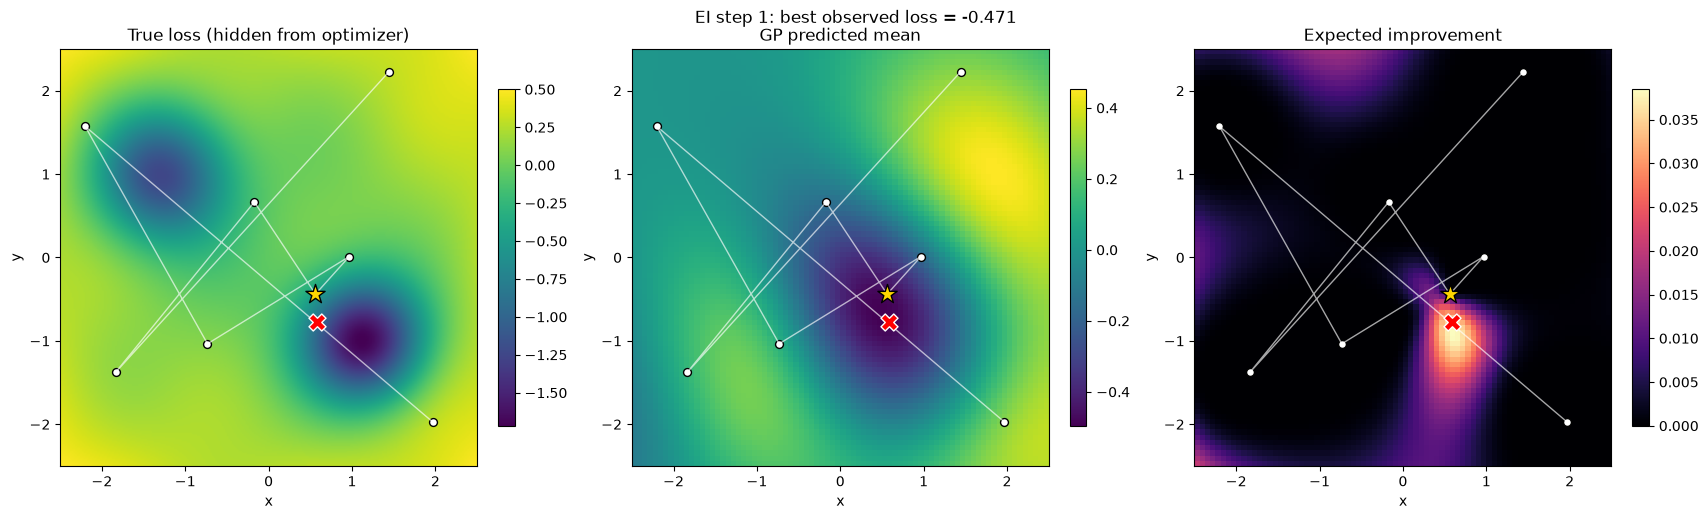

Step 1: tried (+0.584, -0.779); loss=-0.882; best=-0.882


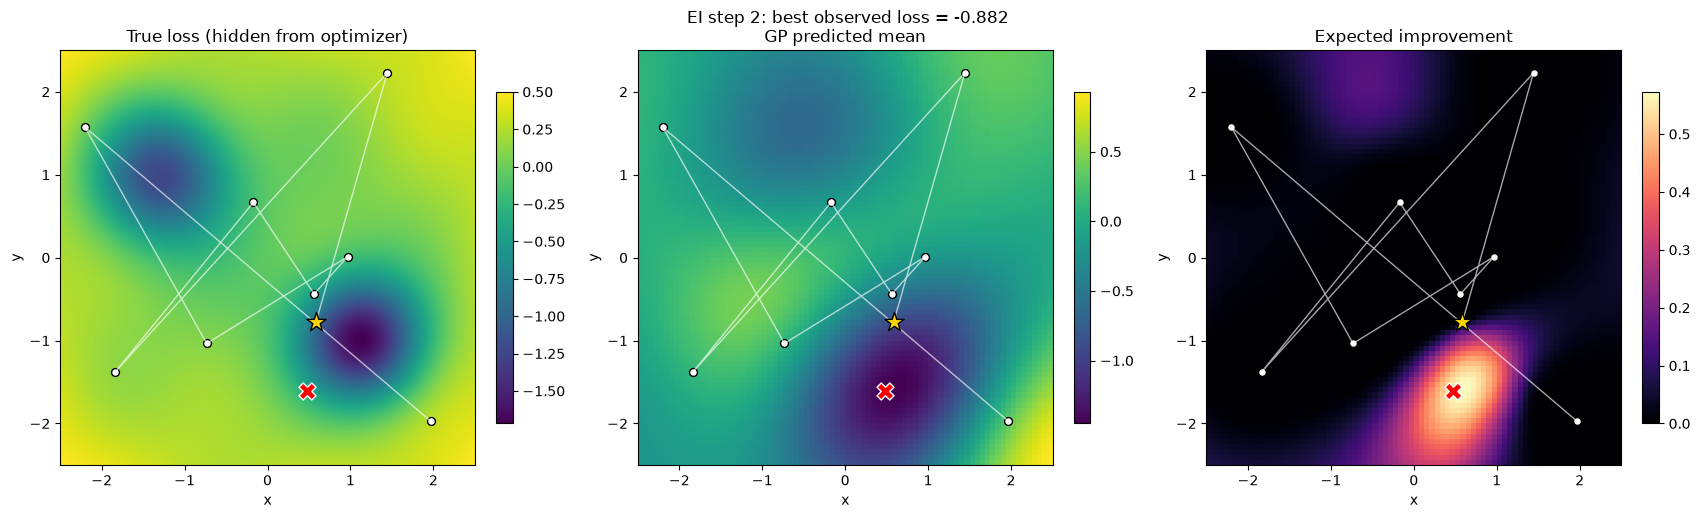

Step 2: tried (+0.476, -1.610); loss=-0.362; best=-0.882


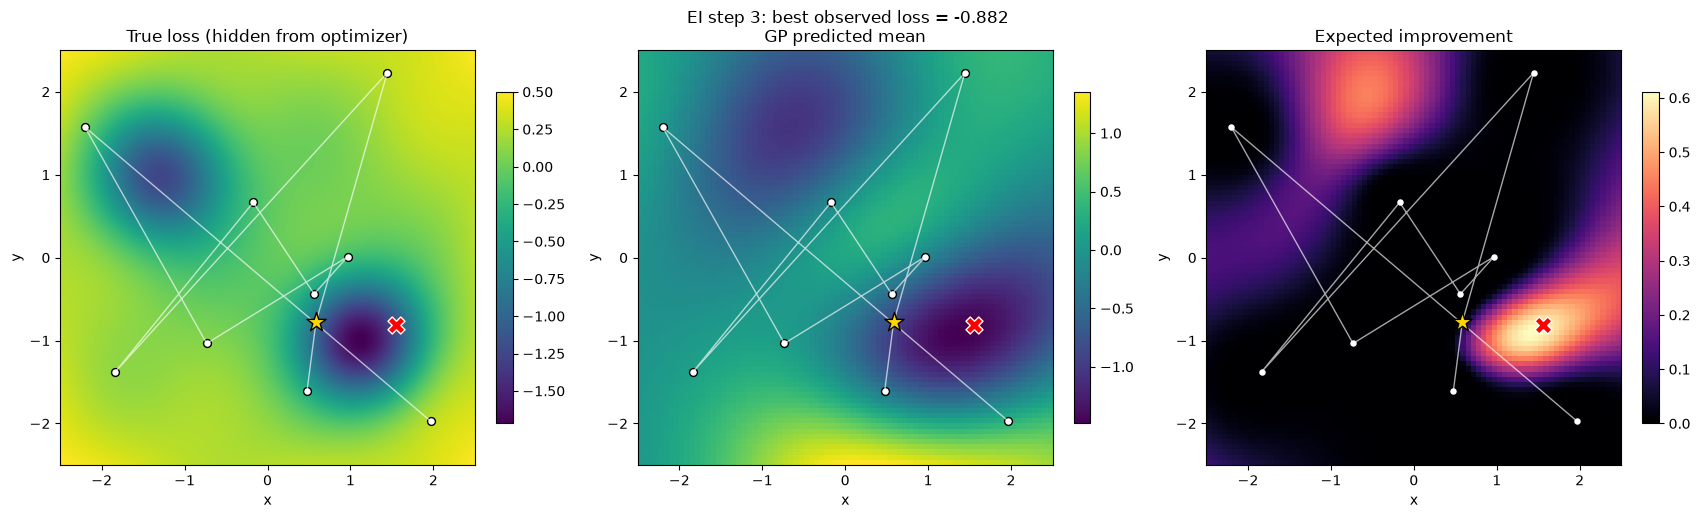

Step 3: tried (+1.552, -0.809); loss=-1.130; best=-1.130


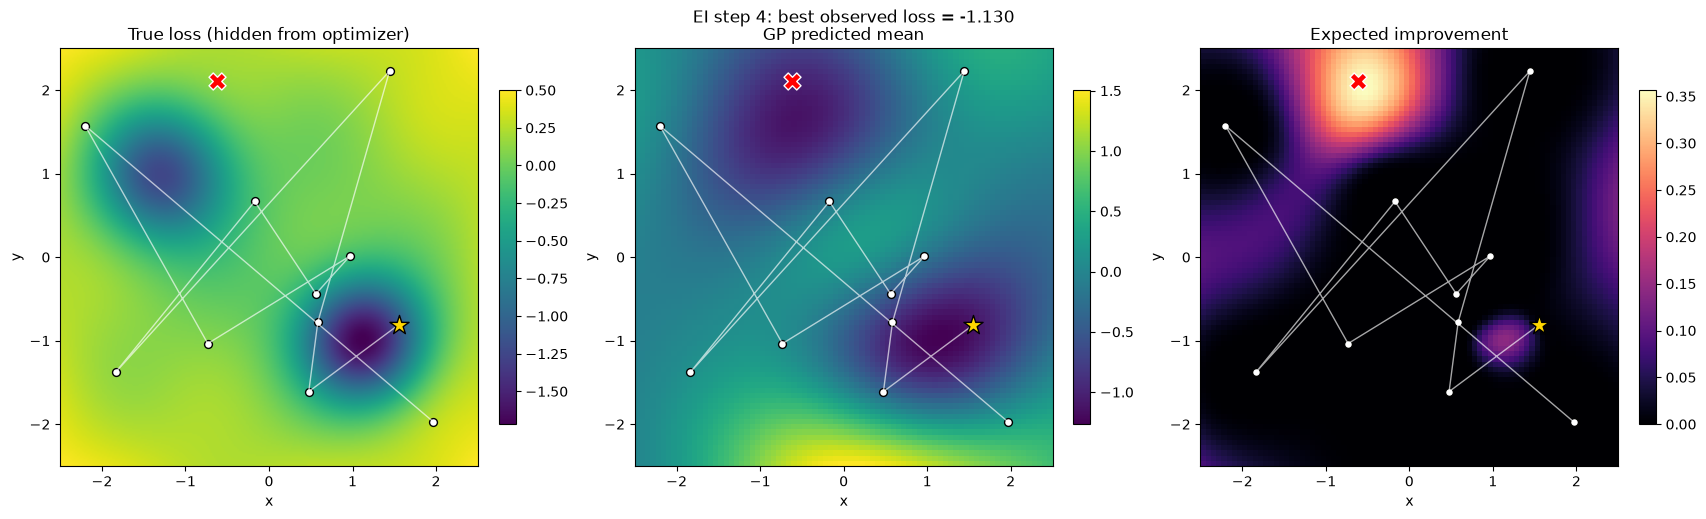

Step 4: tried (-0.617, +2.104); loss=+0.130; best=-1.130


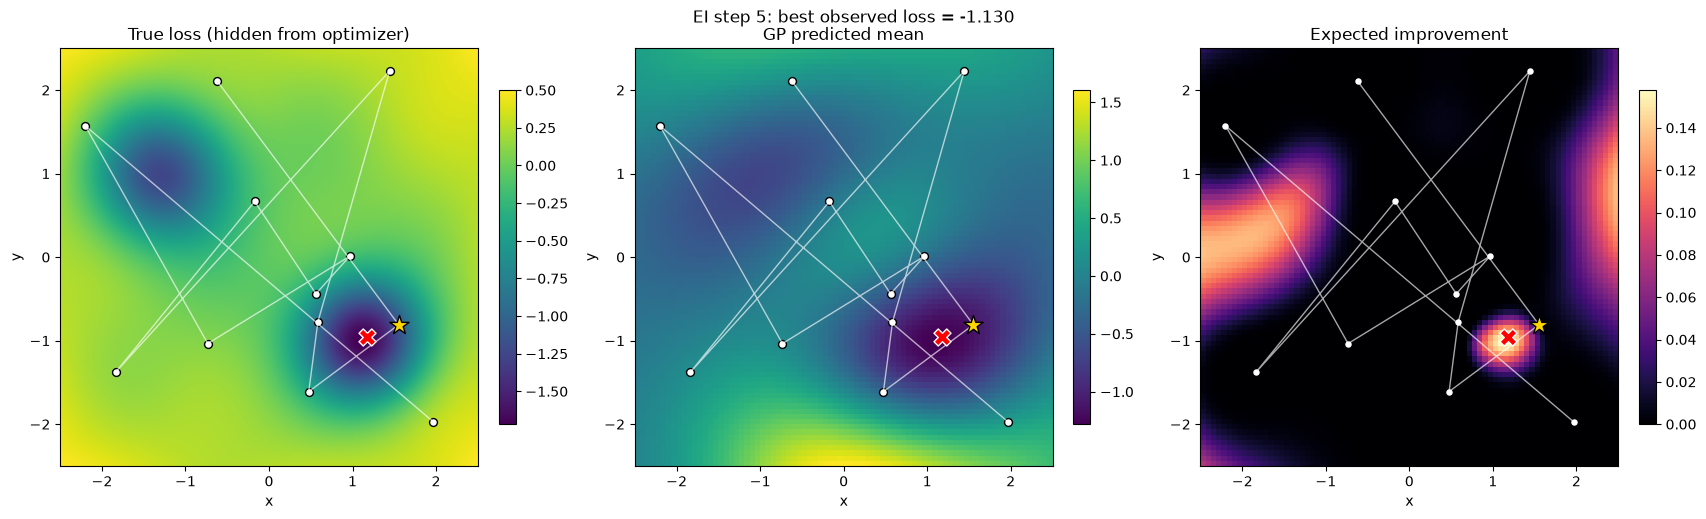

Step 5: tried (+1.175, -0.962); loss=-1.706; best=-1.706


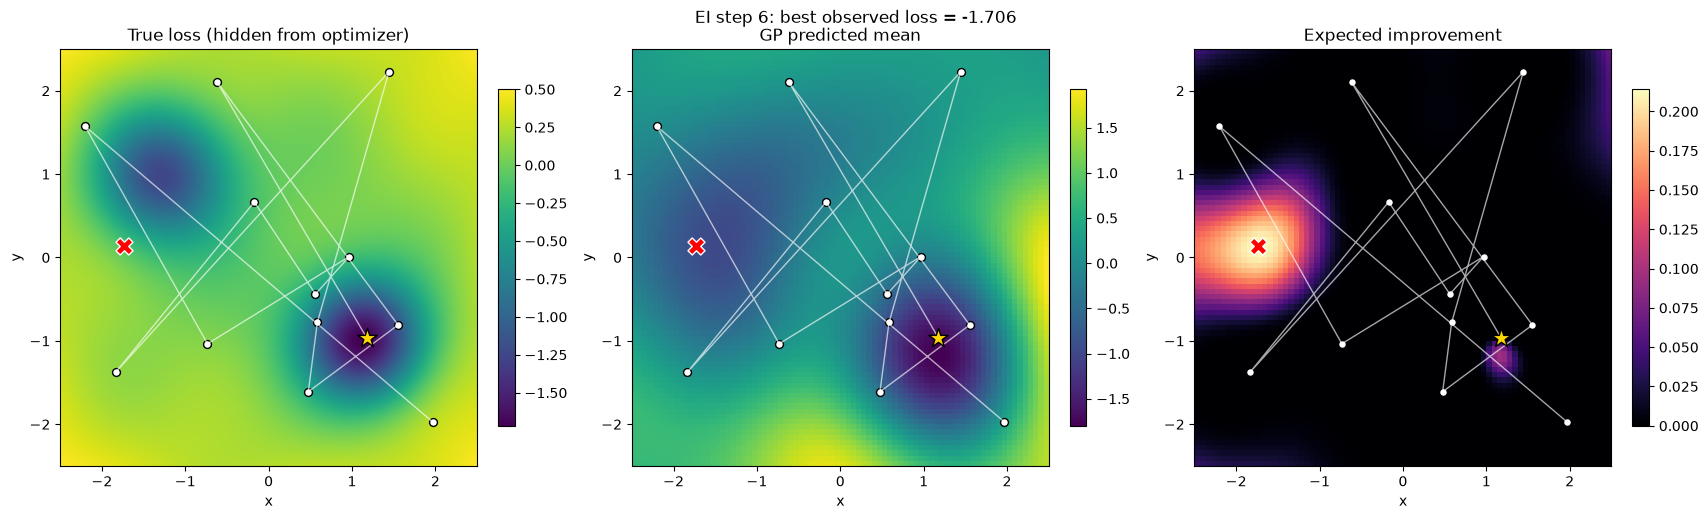

Step 6: tried (-1.734, +0.138); loss=-0.130; best=-1.706


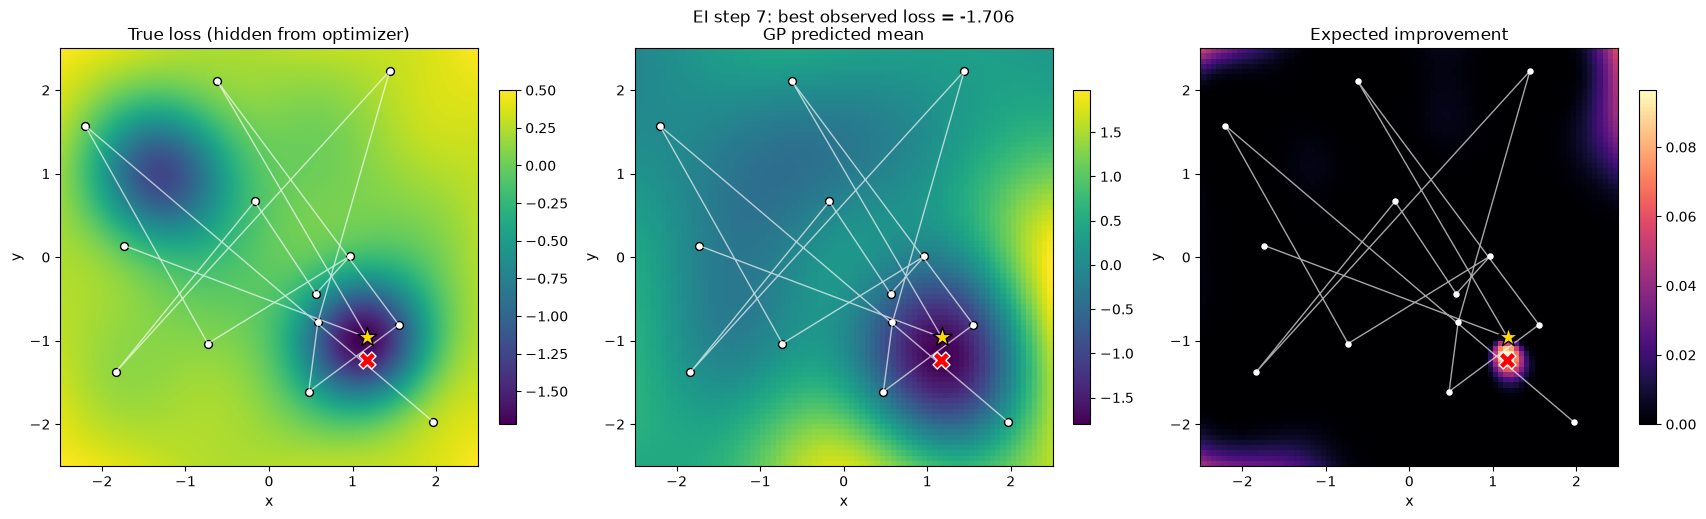

Step 7: tried (+1.170, -1.236); loss=-1.523; best=-1.706


In [4]:
plot_axis = np.linspace(*BOUNDS, 80)
GX, GY = np.meshgrid(plot_axis, plot_axis)
grid_points = np.column_stack([GX.ravel(), GY.ravel()])


def plot_suggestion(opt, trial, iteration):
    completed = [t for t in opt.trials if t.result is not None]
    points = np.array([[t.parameters["x"], t.parameters["y"]] for t in completed])
    best = opt.get_best_trial()
    proposed = trial.parameters

    mean, _ = opt.predict(grid_points)
    ei = opt.acquisition(grid_points)
    fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
    fields = [ZZ, mean.reshape(GX.shape), ei.reshape(GX.shape)]
    titles = ["True loss (hidden from optimizer)", "GP predicted mean", "Expected improvement"]
    cmaps = ["viridis", "viridis", "magma"]

    for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
        image = ax.imshow(field, origin="lower", extent=extent, cmap=cmap, aspect="equal")
        ax.plot(points[:, 0], points[:, 1], color="white", alpha=0.65, linewidth=1)
        ax.scatter(points[:, 0], points[:, 1], s=32, color="white", edgecolor="black")
        ax.scatter(best.parameters["x"], best.parameters["y"], marker="*", s=210,
                   color="gold", edgecolor="black", zorder=5)
        ax.scatter(proposed["x"], proposed["y"], marker="X", s=150,
                   color="red", edgecolor="white", linewidth=1, zorder=6)
        ax.set(xlabel="x", ylabel="y", title=title)
        fig.colorbar(image, ax=ax, shrink=0.8)
    fig.suptitle(f"EI step {iteration}: best observed loss = {best.result:.3f}")
    plt.show()


best_history = [optimizer.get_best_trial().result]
for iteration in range(1, N_EI_STEPS + 1):
    trial = optimizer.get_next_trial()
    plot_suggestion(optimizer, trial, iteration)
    trial.update(float(loss(**trial.parameters)))
    best_history.append(optimizer.get_best_trial().result)
    print(f"Step {iteration}: tried ({trial.parameters['x']:+.3f}, "
          f"{trial.parameters['y']:+.3f}); loss={trial.result:+.3f}; "
          f"best={best_history[-1]:+.3f}")


## 4. Review the path and the best result

The left panel shows every evaluation in order. The right panel shows the best loss observed after each EI step. A minimum estimated from the dense display grid is included as a reference; the optimizer did not use that grid to make decisions.


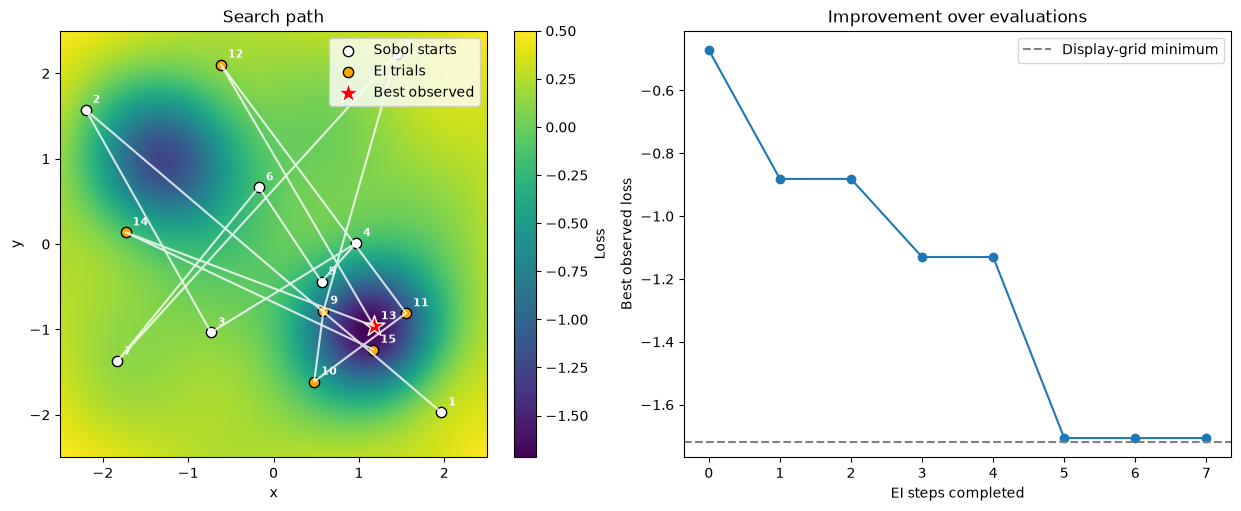

Best observed: x=1.175, y=-0.962, loss=-1.706
Display-grid minimum: x=1.135, y=-0.994, loss=-1.718


In [5]:
points = np.array([[t.parameters["x"], t.parameters["y"]] for t in optimizer.trials])
best = optimizer.get_best_trial()
grid_min = np.unravel_index(np.argmin(ZZ), ZZ.shape)

fig, (ax, ax_trace) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
image = ax.imshow(ZZ, origin="lower", extent=extent, cmap="viridis", aspect="equal")
ax.plot(points[:, 0], points[:, 1], color="white", linewidth=1.5, alpha=0.8)
ax.scatter(points[:N_INITIAL, 0], points[:N_INITIAL, 1], color="white",
           edgecolor="black", s=55, label="Sobol starts")
ax.scatter(points[N_INITIAL:, 0], points[N_INITIAL:, 1], color="orange",
           edgecolor="black", s=55, label="EI trials")
ax.scatter(best.parameters["x"], best.parameters["y"], marker="*",
           color="red", edgecolor="white", s=250, label="Best observed")
for number, (x, y) in enumerate(points, start=1):
    ax.annotate(str(number), (x, y), xytext=(5, 5), textcoords="offset points",
                color="white", fontsize=8, weight="bold")
fig.colorbar(image, ax=ax, label="Loss")
ax.set(xlabel="x", ylabel="y", title="Search path")
ax.legend(loc="upper right")

ax_trace.plot(range(N_EI_STEPS + 1), best_history, marker="o", color="tab:blue")
ax_trace.axhline(ZZ[grid_min], linestyle="--", color="gray", label="Display-grid minimum")
ax_trace.set(xlabel="EI steps completed", ylabel="Best observed loss",
             title="Improvement over evaluations", xticks=range(N_EI_STEPS + 1))
ax_trace.legend()
plt.show()

print(f"Best observed: x={best.parameters['x']:.3f}, y={best.parameters['y']:.3f}, "
      f"loss={best.result:.3f}")
print(f"Display-grid minimum: x={XX[grid_min]:.3f}, y={YY[grid_min]:.3f}, "
      f"loss={ZZ[grid_min]:.3f}")


### Try it yourself

Change `SEED`, `N_INITIAL`, or `N_EI_STEPS` and rerun all cells. Compare when EI explores a new region with when it refines a promising valley. The candidate pool is finite, and a small number of evaluations does not guarantee the global minimum.
